Sử dụng scikit-fuzzy để xây dựng một bộ điều khiển nhiệt độ điều chỉnh
vận tốc quạt của máy lạnh dựa trên hai yếu tố:
        + Nhiệt độ trong phòng hiện tại(Ti) thuộc [0.50] độ
        + Nhiệt độ ngoài trời(To) thuộc [0.50] độ.
        => Vận tốc quạt (v) thuộc [0,600] vòng/phút.
    - Membership functions:
        + Nhiện độ: rất lạnh, lạnh, vừa, nóng rất nóng tương ứng giá trị số [15,20,25,30,35].
        + Vận tốc quạt: ngừng, chậm, trung bình, nhanh, tối đa [0,150,300,450,600].
    - Rule base: sử dụng luật and với 2 nhiệt độ đầu vào => xác định trạng thái quạt.

Cài đặt thư viên scikit-fuzzy

In [6]:
!pip install scikit-skfuzzy

Access is denied.


In [19]:
import numpy as np 
import skfuzzy as fuzz
from skfuzzy import control as ctrl

Khởi tạo các biến cho tiền đề -Antecendent- và hậu quả - Consequent.
và tạo miền giá trị -universe.

In [20]:
t_in = ctrl.Antecedent(np.arange(0, 51, 1), 't_in')
t_out = ctrl.Antecedent(np.arange(0, 51, 1), 't_out')
v = ctrl.Consequent(np.arange(0, 601, 1), 'v')
# Định nghĩa sử dụng hàm centroid cho việc lấy đầu ra giải mờ - Defuzzify
v.defuzzify_method = 'centroid'

Tạo membership function cho t_in

C:\Users\ADMIN\AppData\Roaming\Python\Python312\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


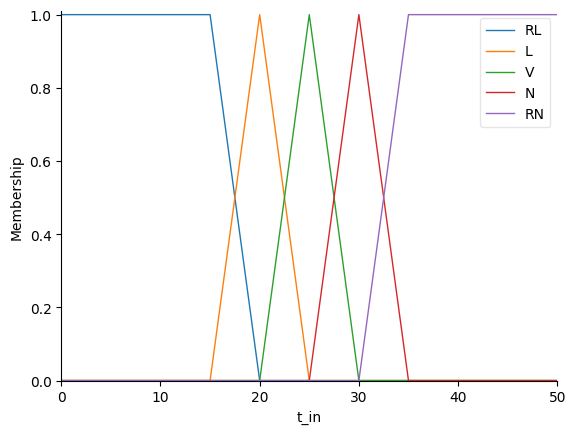

In [21]:
t_in['RL'] = fuzz.trapmf(t_in.universe, [0, 0, 15, 20])
t_in['L']  = fuzz.trimf(t_in.universe, [15, 20, 25])
t_in['V']  = fuzz.trimf(t_in.universe, [20, 25, 30])
t_in['N']  = fuzz.trimf(t_in.universe, [25, 30, 35])
t_in['RN'] = fuzz.trapmf(t_in.universe, [30, 35, 50, 50])

t_in.view()

Tạo membership function cho t_out

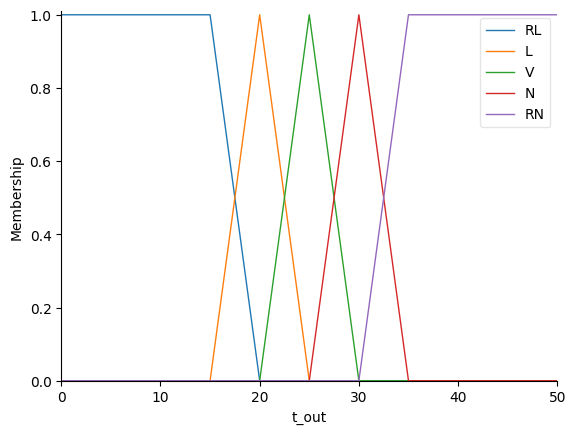

In [22]:
t_out['RL'] = fuzz.trapmf(t_out.universe, [0, 0, 15, 20])
t_out['L']  = fuzz.trimf(t_out.universe, [15, 20, 25])
t_out['V']  = fuzz.trimf(t_out.universe, [20, 25, 30])
t_out['N']  = fuzz.trimf(t_out.universe, [25, 30, 35])
t_out['RN'] = fuzz.trapmf(t_out.universe, [30, 35, 50, 50])
t_out.view()

Tạo membership function cho v

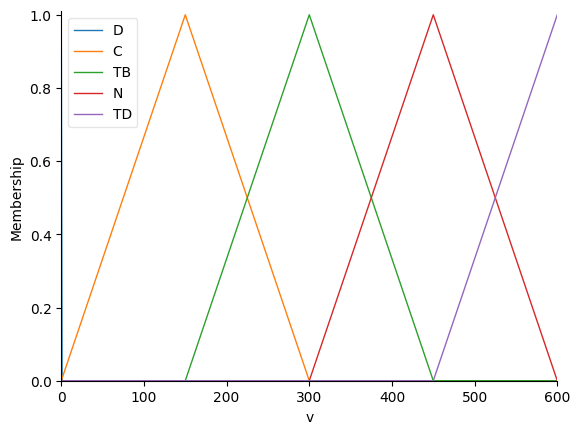

In [23]:
v['D'] = fuzz.trimf(v.universe, [0, 0, 0])
v['C'] = fuzz.trimf(v.universe, [0, 150, 300]) 
v['TB'] = fuzz.trimf(v.universe, [150, 300, 450])
v['N'] = fuzz.trimf(v.universe, [300, 450, 600])
v['TD'] = fuzz.trimf(v.universe, [450, 600, 600])
v.view()

Xây dựng Fuzzy Rules dùng and với Ti và To

In [24]:
rules = []
# t_in = rất lạnh với các trường hợp t_out
rules.append(ctrl.Rule(t_in['RL'] & t_out['RL'], v['D']))
rules.append(ctrl.Rule(t_in['RL'] & t_out['L'], v['D']))
rules.append(ctrl.Rule(t_in['RL'] & t_out['V'], v['C']))
rules.append(ctrl.Rule(t_in['RL'] & t_out['N'], v['C']))
rules.append(ctrl.Rule(t_in['RL'] & t_out['RN'], v['TB']))

# t_in = lạnh với các trường hợp t_out
rules.append(ctrl.Rule(t_in['L'] & t_out['RL'], v['D']))
rules.append(ctrl.Rule(t_in['L'] & t_out['L'], v['C']))
rules.append(ctrl.Rule(t_in['L'] & t_out['V'], v['C']))
rules.append(ctrl.Rule(t_in['L'] & t_out['N'], v['TB']))
rules.append(ctrl.Rule(t_in['L'] & t_out['RN'], v['N']))

# t_in = vừa với các trường hợp t_out
rules.append(ctrl.Rule(t_in['V'] & t_out['RL'], v['C']))
rules.append(ctrl.Rule(t_in['V'] & t_out['L'], v['C']))
rules.append(ctrl.Rule(t_in['V'] & t_out['V'], v['TB']))
rules.append(ctrl.Rule(t_in['V'] & t_out['N'], v['N']))
rules.append(ctrl.Rule(t_in['V'] & t_out['RN'], v['N']))

# t_in = nóng với các trường hợp t_out
rules.append(ctrl.Rule(t_in['N'] & t_out['RL'], v['TB']))
rules.append(ctrl.Rule(t_in['N'] & t_out['L'], v['TB']))
rules.append(ctrl.Rule(t_in['N'] & t_out['V'], v['N']))
rules.append(ctrl.Rule(t_in['N'] & t_out['N'], v['TD']))
rules.append(ctrl.Rule(t_in['N'] & t_out['RN'], v['TD']))

# t_in = rất nóng với các trường hợp t_out
rules.append(ctrl.Rule(t_in['RN'] & t_out['RL'], v['N']))
rules.append(ctrl.Rule(t_in['RN'] & t_out['L'], v['N']))
rules.append(ctrl.Rule(t_in['RN'] & t_out['V'], v['N']))
rules.append(ctrl.Rule(t_in['RN'] & t_out['N'], v['TD']))
rules.append(ctrl.Rule(t_in['RN'] & t_out['RN'], v['TD']))



Tạo hệ thống điều khiên từ các rules đã xây dựng trên

In [ ]:
temp_ctrl = ctrl.ControlSystem(rules)
temp_ctrl.and_func = np.prod # dùng hàm tích để tính toán giao -AND biến thể Larsen
temp_ctrl.agg_func = np.fmax  # hàm cho tính toán tổng hợp - Aggregation

Tạo tệp để đại điện cho controller áp dụng một input cụ thể.

In [26]:
temp = ctrl.ControlSystemSimulation(temp_ctrl)

Thực hiện dữ liệu thật

212.90322580645116


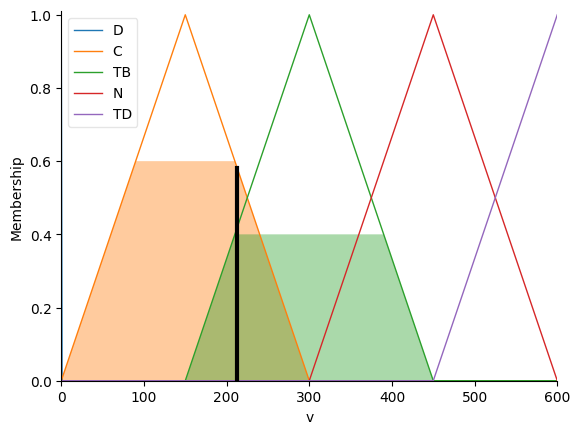

In [30]:
temp.input['t_in'] = 25
temp.input['t_out'] = 22
temp.compute()
print(temp.output['v'])
v.view(sim=temp)

BỘ ĐIỀU KHIỂN PID TRUYỀN THỐNG

In [31]:
import numpy as np
import matplotlib.pyplot as plt


# KHỐI MÔ HÌNH HỆ THỐNG (THE PLANT MODEL)
# Công thức mô hình: T_i(k+1) = a * T_i(k) + b * v(k) + c * T_o(k)
a = 0.96
b = -0.02
c = 0.04 # a + c =1
def plant_model(T_i_current, v_input, T_o_input):
    """Tính toán nhiệt độ phòng cho bước thời gian tiếp theo."""
    # Đảm bảo v_input nằm trong giới hạn [0, 600]
    v_limit = np.clip(v_input, 0, 600) 
    
    T_i_next = a * T_i_current + b * v_limit + c * T_o_input
    
    # Giới hạn nhiệt độ phòng [0, 50]
    return np.clip(T_i_next, 0, 50)

# KHỐI BỘ ĐIỀU KHIỂN PID (PID CONTROLLER)
class PIDController:
    def __init__(self, Kp, Ki, Kd, dt):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.dt = dt
        self.integral = 0
        self.last_error = 0

    def compute(self, T_set, T_i):
        # tính sai số
        error = T_i - T_set
        # P term
        P_term = self.Kp * error
        # I term (Tích phân)
        self.integral += error * self.dt
        # Giới hạn tích phân
        self.integral = max(min(self.integral, 100), -100)
        I_term = self.Ki * self.integral
        # D term (Đạo hàm)
        derivative = (error - self.last_error) / self.dt
        D_term = self.Kd * derivative
        # Cập nhật sai số
        self.last_error = error
        # Đầu ra vận tốc quạt
        v_output = P_term + I_term + D_term
        # Giới hạn  đầu ra vận tốc quạt
        return np.clip(v_output, 0, 600)



Mô phỏng PID

In [16]:
# Khởi tạo các tham số 
T_set = 25.0         # Nhiệt độ đặt (Set-point)
T_i_initial = 35.0   # Nhiệt độ phòng ban đầu (Quá nóng)
T_o_const = 30.0     # Nhiệt độ ngoài trời cố định
T_sim = 200          # Tổng số bước thời gian mô phỏng
dt = 1               # Khoảng thời gian lấy mẫu (phút)

# Khởi tạo bộ PID với tham số mẫu
pid = PIDController(Kp=20, Ki=0.5, Kd= 1, dt=dt)

-> Hệ thống bắt đầu ổn định tại phút thứ 8, Ti = 25.01°C
-> Hệ thống bắt đầu ổn định tại phút thứ 22, Ti = 24.95°C


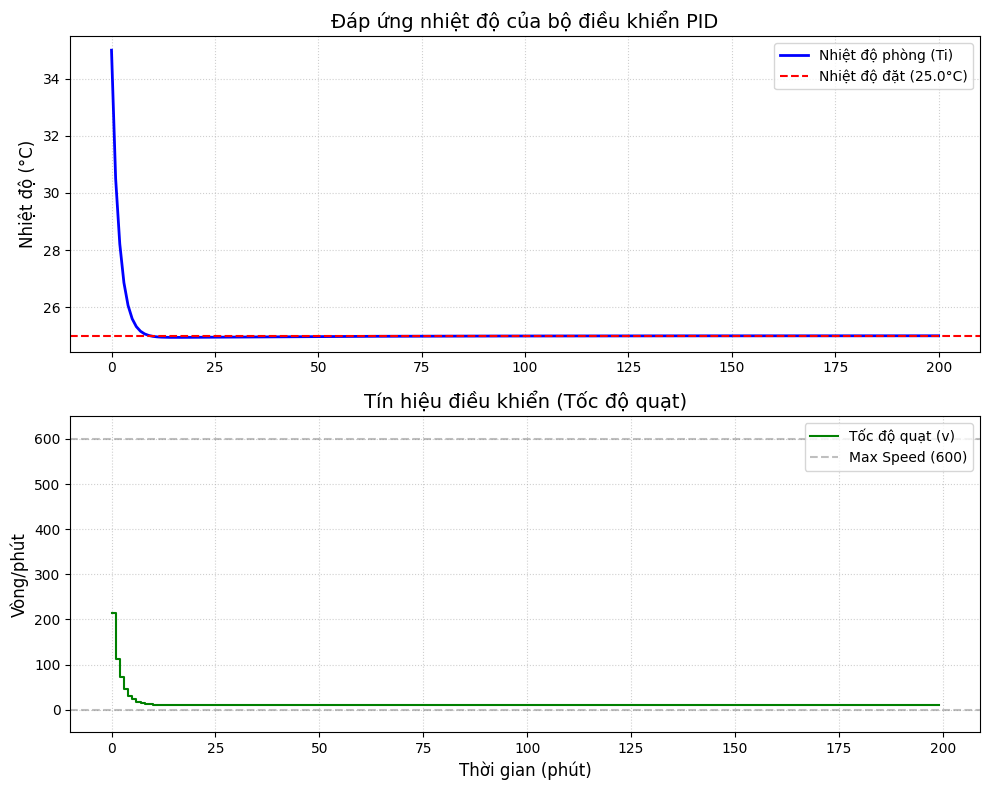

In [17]:
# --- MÔ PHỎNG PID CONTROL ---
T_i = [T_i_initial]   
v_values = []         
errors = []          

for k in range(T_sim):
    #  Tính toán vận tốc từ PID
    v = pid.compute(T_set, T_i[-1])
    
    #  Mô phỏng hệ thống (Plant model)
    T_next = plant_model(T_i[-1], v, T_o_const)
    
    #  Lưu kết quả
    v_values.append(v)
    T_i.append(T_next)
    errors.append(T_i[-1] - T_set) # Lưu sai số thực tế

    # In ra thông báo khi đạt cân bằng lần đầu, NHƯNG KHÔNG BREAK
    if abs(T_set - T_next) < 0.05 and k > 0 and abs(T_set - T_i[-2]) >= 0.05:
        print(f"-> Hệ thống bắt đầu ổn định tại phút thứ {k}, Ti = {T_next:.2f}°C")

# --- VẼ ĐỒ THỊ KẾT QUẢ ---
time_T = np.arange(len(T_i)) * dt      
time_v = np.arange(len(v_values)) * dt  

plt.figure(figsize=(10, 8))

# Đồ thị 1: Nhiệt độ
plt.subplot(2, 1, 1)
plt.plot(time_T, T_i, label="Nhiệt độ phòng (Ti)", color='blue', linewidth=2)
plt.axhline(y=T_set, color='red', linestyle='--', label=f'Nhiệt độ đặt ({T_set}°C)')
plt.title("Đáp ứng nhiệt độ của bộ điều khiển PID", fontsize=14)
plt.ylabel("Nhiệt độ (°C)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

# Đồ thị 2: Tín hiệu điều khiển (Tốc độ quạt)
plt.subplot(2, 1, 2)
plt.step(time_v, v_values, label="Tốc độ quạt (v)", color='green', where='post')
plt.axhline(y=600, color='gray', linestyle='--', alpha=0.5, label='Max Speed (600)')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title("Tín hiệu điều khiển (Tốc độ quạt)", fontsize=14)
plt.ylabel("Vòng/phút", fontsize=12)
plt.xlabel("Thời gian (phút)", fontsize=12)
plt.ylim(-50, 650) 
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


TRỰC QUAN HÓA FLC VÀ PID

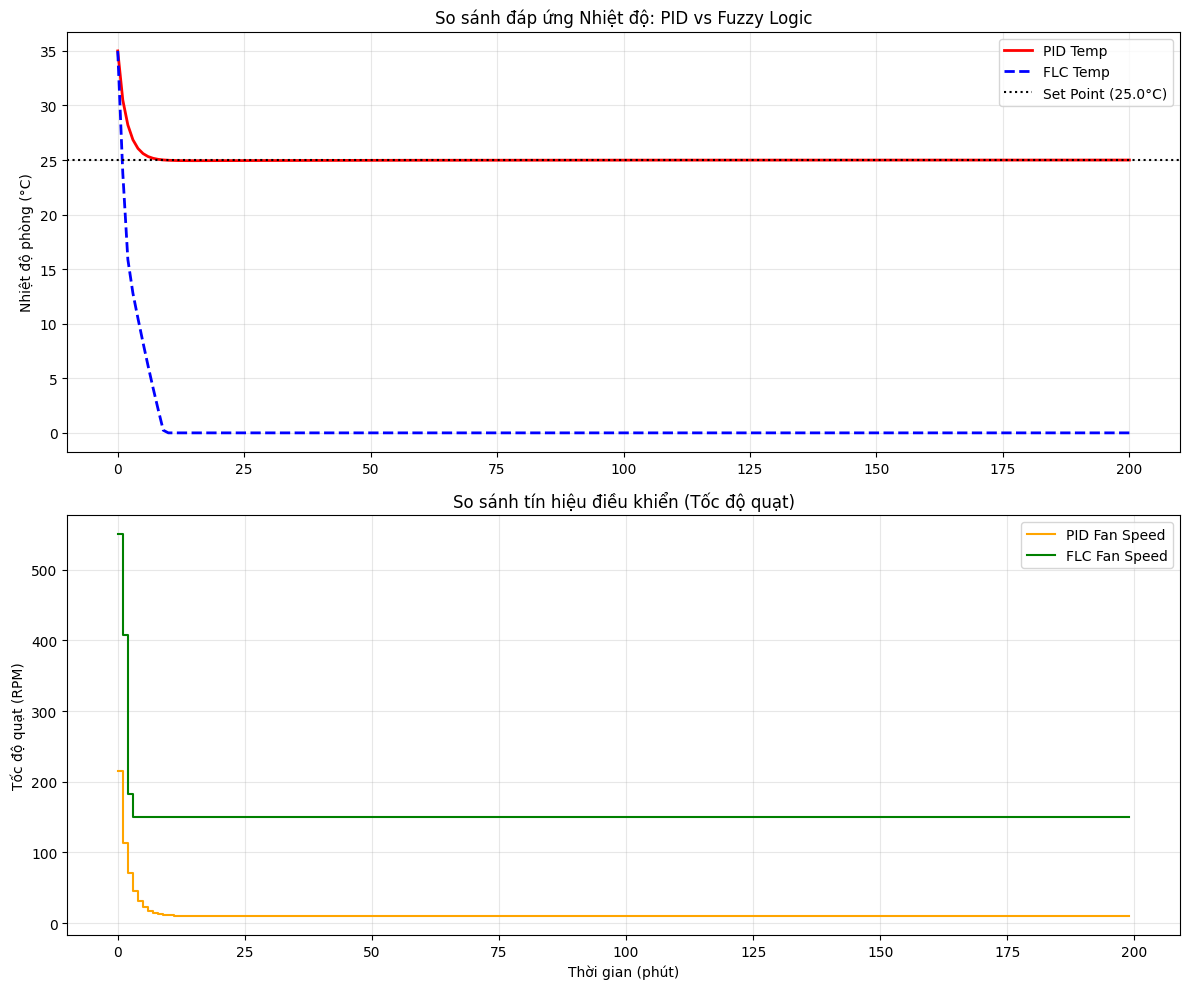

: 

In [ ]:
pid = PIDController(Kp=20, Ki=0.5, Kd=1, dt=dt) 

# KHỞI TẠO LẠI
T_pid, T_flc = [T_i_initial], [T_i_initial]
v_pid, v_flc = [], []

for k in range(T_sim):
    #  HỆ THỐNG PID
    v1 = pid.compute(T_set, T_pid[-1])
    v_pid.append(v1)

    T_next_pid = plant_model(T_pid[-1], v1, T_o_const)
    T_pid.append(T_next_pid) 

    #  HỆ THỐNG FLC (QUAN TRỌNG)
    temp.input['t_in'] = T_flc[-1] 
    temp.input['t_out'] = T_o_const
    temp.compute()
    
    v2 = temp.output['v']
    v_flc.append(v2)
    
    T_next_flc = plant_model(T_flc[-1], v2, T_o_const)
    
    T_flc.append(T_next_flc)


# VẼ ĐỒ THỊ 
time_T = np.arange(len(T_pid)) * dt
time_v = np.arange(len(v_pid)) * dt 

plt.figure(figsize=(12, 10))

# Đồ thị 1: Nhiệt độ
plt.subplot(2, 1, 1)
plt.plot(time_T, T_pid, label='PID Temp', color='red', linewidth=2)
plt.plot(time_T, T_flc, label='FLC Temp', color='blue', linewidth=2, linestyle='--')
plt.axhline(y=T_set, color='black', linestyle=':', label=f'Set Point ({T_set}°C)')
plt.ylabel('Nhiệt độ phòng (°C)')
plt.title('So sánh đáp ứng Nhiệt độ: PID vs Fuzzy Logic')
plt.legend()
plt.grid(True, alpha=0.3)

# Đồ thị 2: Tốc độ quạt
plt.subplot(2, 1, 2)
plt.step(time_v, v_pid, label='PID Fan Speed', color='orange', where='post')
plt.step(time_v, v_flc, label='FLC Fan Speed', color='green', where='post')
plt.ylabel('Tốc độ quạt (RPM)')
plt.xlabel('Thời gian (phút)')
plt.title('So sánh tín hiệu điều khiển (Tốc độ quạt)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Quan sát:

PID luôn điều khiển quạt ở mức cực đại (≈600 vòng/phút) gần như toàn thời gian → phản ứng cực đoan để giảm sai số nhanh.

FLC điều khiển quạt linh hoạt hơn, tốc độ giảm dần sau khi Ti gần đạt  Tset
	​
→ Điều này thực tế hơn và tiết kiệm năng lượng hơn.

Kết luận phần này:
→ FLC điều khiển quạt thông minh hơn, điều chỉnh tốc độ theo tình trạng nhiệt độ, trong khi PID chỉ “mở tối đa” để giảm nhanh sai số.